**Notes on Python virtual environment**

To activate the virtual environment, fix Windows bug then activate:
1. `Set-ExecutionPolicy Unrestricted -Scope Process`
2. `.venv\Scripts\activate`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from algorithms import alg_pdtr, alg_midas
import sklearn.datasets as skdata
import sklearn.preprocessing as skprepro
import pickle

In [2]:
# Operators
def JA(z, tau, data=None):
    r"""
    Compute resolvent J_{\tau\mathbf{A}}(z) = (J_{\tau_1 A_1}(z1), ..., J_{\tau A_N}(zN))
    :param z: (N, xd+yd) array
    :param tau: step size.
    :param data: not used, included for compatibility with algorithms.py
    return: z
    """
    if isinstance(tau, float):
        return z.copy()
    else:
        return  z.copy()

def B(z, data=None):
    r"""
    Evaulate operator \mathbf{B}(z) = (B1(z1), ..., BN(zN)).
    :param z: (N, xd+yd*N) array
    :param data: coefficient matrix A=(A[1],...,A[N]), target vector y0, penalty parameter \lambda
    """
    A, y0, Lambda = data['A'], data['y0'], data['lambda']
    N, yd, xd = A.shape
    Bz = np.zeros_like(z)
    for ii in range(N):
        # Extract and reshape x^+, x^- and y^+, y^- components
        x, yi = np.array(z[ii, :xd]), np.array(z[ii, xd+yd*ii:xd+yd*(ii+1)])
        y0i = np.array(y0[yd*ii:yd*(ii+1)])
        Ai = A[ii]   # agent i's coefficient matrix
        Aix_yi = Ai@x - yi # Ai^T x - yi
        # Compute Bz for x and y components, agent i's own variables
        Bz[ii, :xd] = 2*Ai.T@(Aix_yi)
        Bz[ii, xd+yd*ii:xd+yd*(ii+1)] = 2 * (Aix_yi + Lambda*(yi-y0i))  # leave y_j entries 0
    return Bz

In [3]:
# Performance metrics
def residue(x, y, tau):
    r""" 'Normalised' distance between iterates, $||x-y||_{\Lambda^{-1}}$ """
    if isinstance(tau, float):
        return np.linalg.norm(x - y)/tau
    else:
        tauinvsqrt = np.divide(1, np.sqrt(tau), where=(tau!=0))
        return  np.linalg.norm(tauinvsqrt @(x - y))

def relerror(z, zsol):
    """ Distance from reference solution to agents' iterate """
    return np.linalg.norm(z - zsol)/np.linalg.norm(zsol) # broadcasting zsol

In [4]:
# Robust least squares - dataset
rng_gen = np.random.default_rng(2025)
N = 10
dataset = 'synthetic' # 'synthetic' or 'california'

if dataset == 'synthetic':
    with open(f'rls_synthetic', 'rb') as f:
        Xdict, ydict = pickle.load(f)
        X, ytilde  =Xdict[0], ydict[0]
        ydim, xdim = X.shape[0]//N, X.shape[1]

elif dataset == 'california':
    # California dataset
    subset = 200
    penalty = 50 # lambda penalty parameter
    X, ytilde = skdata.fetch_california_housing(return_X_y=True)
    X, ytilde = X[:subset], ytilde[:subset]
    # X = skprepro.StandardScaler().fit_transform(X)

ydim, xdim = X.shape[0]//N, X.shape[1]
Xsplit = np.array([X[ydim*ii:ydim*(ii+1),:] for ii in range(N)])  # spilt into N sections
datadict = {'A': Xsplit, 'y0': ytilde, 'lambda': penalty}
# Exact solution
xstar = np.linalg.solve(X.T@X, penalty/(penalty-2)*X.T@ytilde)
ystar = (1/(penalty-1))*(X@xstar + penalty*ytilde)
zstar = np.hstack([xstar, ystar])
# print(np.linalg.norm(X.T@X@xstar - X.T@ystar))
# print(np.linalg.norm(-X@xstar - penalty*ytilde + (penalty-1)*ystar))

In [5]:
# Algorithm parameters
G = nx.cycle_graph(N)
Lap = nx.laplacian_matrix(G).todense()  # Laplacian
alpha = 0.501 * np.max(np.linalg.eigvalsh(Lap))    # alpha satisfies (1/2) * lambda_max(Lap) < alpha <= (2/3) * lambda_max(Lap)
W = np.eye(N) - Lap / alpha

Xnorm = np.linalg.norm(Xsplit, ord=2, axis=(1,2))
L = np.array([  # Lipschitz constants for B_i -> \sqrt2 * \max{|Ai|\sqrt(|Ai|^2+1), \sqrt(|Ai|^2+\lambda-1)}
    np.sqrt(2)*np.max([Xnorm[ii]*np.sqrt(Xnorm[ii]**2+1), np.sqrt(Xnorm[ii]**2+penalty-1)]) for ii in range(N)
    ])

tau_m = 0.9 * np.diag(1/(8 * L))
tau_m_same = 0.9/8/max(L)*np.eye(N)
tau_p = 0.9 * (1 + np.min(np.linalg.eigvalsh(W))) / (4 * max(L))
betamax = 0.9/np.max(tau_m)
betanorm = 0.9/np.linalg.norm(np.sqrt(tau_m)@((np.eye(N)-W)/2)@np.sqrt(tau_m), ord=2)    # \beta = 1/||tau^(1/2)*((I-W)/2)*tau^(1/2))||

In [6]:
# Lsyn = np.array([1392.4669692,  1468.28543567, 1464.16872095, 1429.77631823, 1456.37180118, 1414.93900188, 1468.11546123, 1481.29141598, 1453.32803637, 1444.56523867])
# Lcali  = np.array([98.69485047,  71.46720949,  65.40363687, 211.17574407, 187.37319541, 94.01898321, 290.30154503, 147.59134575, 54.13511064, 127.74729495])

# Lsyn_scaled = Lsyn/max(Lsyn)
# Lsyn_entropy = -np.sum(Lsyn_scaled*np.log(Lsyn_scaled))
# Lcali_scaled = Lcali/max(Lcali)
# Lcali_entropy = -np.sum(Lsyn_scaled*np.log(Lcali_scaled))
# print('Synthetic:')
# print(f'Norm. range = {max(Lsyn_scaled)-min(Lsyn_scaled)}')
# print(f'Shannon entropy = {Lsyn_entropy}')

# print('Calfornia:')
# print(f'Norm. range = {max(Lcali_scaled)-min(Lcali_scaled)}')
# print(f'Shannon entropy = {Lcali_entropy}')


In [7]:
# Run algorithms
maxit = 10000

z0 = rng_gen.random((N, xdim+ydim*N))
z0 *= 10/np.linalg.norm(z0)
# z0 = np.zeros((N, xdim+ydim*N))
xs1,rel1,res1, time1 = alg_midas(z0, JA, B, W, tau_m, residue, lambda z: relerror(z, zstar), max_iters=maxit, data=datadict, beta=betamax)
print('')
xs1b, rel1b, res1b, time1b = alg_midas(z0, JA, B, W, tau_m, residue, lambda z: relerror(z, zstar), max_iters=maxit, data=datadict, beta=betanorm)
print('')
xs1c, rel1c, res1c, time1c = alg_midas(z0, JA, B, W, tau_m_same, residue, lambda z: relerror(z, zstar), max_iters=maxit, data=datadict, beta=betamax)
print('')
xs2, rel2, res2, time2 = alg_pdtr(z0, JA, B, W, tau_p, residue, lambda z: relerror(z, zstar), max_iters=maxit, data=datadict)

MIDAS: iteration 10000 of 10000
MIDAS: iteration 10000 of 10000
MIDAS: iteration 10000 of 10000


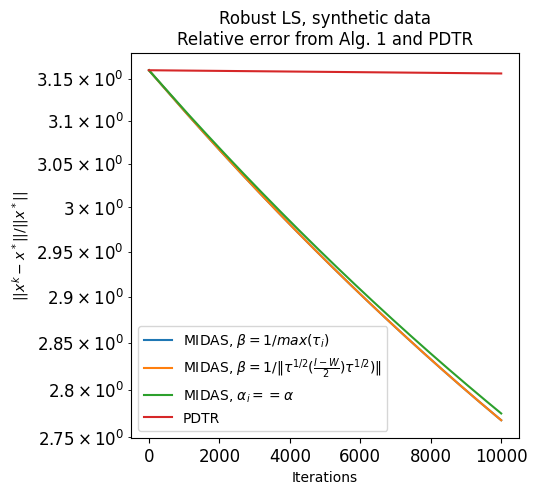

In [ ]:
# Plot relative error
fig_rel = plt.figure(figsize=(5, 5))
ax_rel = fig_rel.add_subplot(111)
ax_rel.semilogy(rel1, label=r'MIDAS, $\beta=1/max(\tau_i)$')
ax_rel.semilogy(rel1b, label=r'MIDAS, $\beta=1/\|\tau^{1/2}(\frac{I-W}{2})\tau^{1/2})\|$')
ax_rel.semilogy(rel1c, label=r'MIDAS, $\alpha_i==\alpha$')
ax_rel.semilogy(rel2, label='PDTR')
ax_rel.set_xlabel("Iterations")
ax_rel.set_ylabel("$||x^k-x^*||/||x^*||$")
ax_rel.set_title(f"Robust LS, {dataset} data\nRelative error from Alg. 1 and PDTR")
ax_rel.tick_params(axis='both', which='both', labelsize=12)
# ax_rel.text(0.5, 0.5, L, transform=ax_rel.transAxes, wrap=True)
ax_rel.legend()

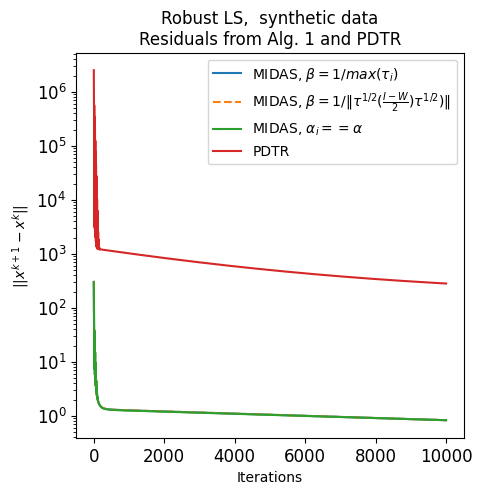

In [9]:
# ------ Residuals plot ----------
fig_res = plt.figure(figsize=(5, 5))
ax_res = fig_res.add_subplot(111)
ax_res.semilogy(res1[1:], label=r'MIDAS, $\beta=1/max(\tau_i)$')
ax_res.semilogy(res1b[1:], '--', label=r'MIDAS, $\beta=1/\|\tau^{1/2}(\frac{I-W}{2})\tau^{1/2})\|$')
ax_res.semilogy(res1c[1:], label=r'MIDAS, $\alpha_i==\alpha$')
ax_res.semilogy(res2[1:], label='PDTR')
ax_res.set_xlabel("Iterations")
ax_res.set_ylabel("$||x^{k+1}-x^k||$")
ax_res.set_title(f"Robust LS,  {dataset} data\nResiduals from Alg. 1 and PDTR")
ax_res.tick_params(axis='both', which='both', labelsize=12)
# ax_res.text(0.5, 0.5, L, transform=ax_res.transAxes, wrap=True)
ax_res.legend()